# P-values and Hypothesis Test Setup

Foundation of hypothesis testing covering p-values, null and alternative hypotheses, one-sided vs two-sided tests.


# 1. P-Values and Hypothesis Test Setup

You run an A/B test and your new checkout flow shows a 3% higher conversion rate. Is this a real improvement, or just random noise? A clinical trial finds that patients on a new medication have lower blood pressure than those on placebo. Should doctors start prescribing it? Your manufacturing line produces widgets with an average weight that seems off from the specification. Is the machine miscalibrated, or are you just seeing normal variation?

These questions share a common structure: you have data, you have a claim, and you need to decide whether the data support the claim or whether what you're seeing could easily happen by chance. Hypothesis testing provides the framework for making these decisions rigorously, quantifying the strength of evidence so you can make informed choices rather than guessing.

This notebook is the first in a series on hypothesis testing. Here, we establish the foundational concepts that everything else builds upon: what p-values really mean, how to set up null and alternative hypotheses, the difference between one-sided and two-sided tests, and how test statistics translate raw data into evidence. Master these fundamentals, and the specific tests covered in later chapters (z-tests, t-tests, F-tests, ANOVA) will feel like natural applications of the same core logic.

## 2. The Logic Of Hypothesis Testing

Before diving into formulas, let's understand the reasoning that makes hypothesis testing work. The logic is elegant but counterintuitive: we don't try to prove what we believe is true. Instead, we assume the opposite and see if the data make that assumption look ridiculous.

Imagine you flip a coin 100 times and get 63 heads. You suspect the coin might be biased toward heads. How would you go about testing this suspicion?
The direct approach, trying to prove the coin is biased, runs into an immediate problem: what does "biased" mean exactly? A coin that lands heads 51% of the time is biased, but so is a coin that lands heads 99% of the time.here are infinitely many ways a coin could be biased, so you can't calculate the probability of "biased" without specifying exactly how biased.

The indirect approach works much better. Start by assuming the coin is fair (50% heads). Under this assumption, calculate the probability of getting 63 or more heads in 100 flips. If this probability is very small, say 1%, then either:

1. The coin really is fair, and you just witnessed something that happens only 1% of the time, or
2. The coin isn't fair, and what you witnessed is quite likely


When the probability is small enough, option (2) becomes more plausible than option (1). You reject the assumption that the coin is fair.

This is the essence of hypothesis testing: assume nothing interesting is happening (the **null hypothesis**), calculate how surprising your data would be under that assumption (the **p-value**), and reject the assumption if the data are surprising enough.

## 3. What is P-Value(and Isn't)

The p-value is the most misunderstood concept in statistics, but it becomes simple once you internalize what question it answers.

>P-Value Definition
>The p-value is the probability of observing data at least as extreme as what you observed, assuming the null hypothesis is true.

Let's unpack this carefully with our coin example. You flipped 100 times, got 63 heads, and the null hypothesis says P(heads) = 0.5. The p-value asks: if the coin really were fair, how often would you see 63 or more heads (or, for a two-sided test, also 37 or fewer heads)?

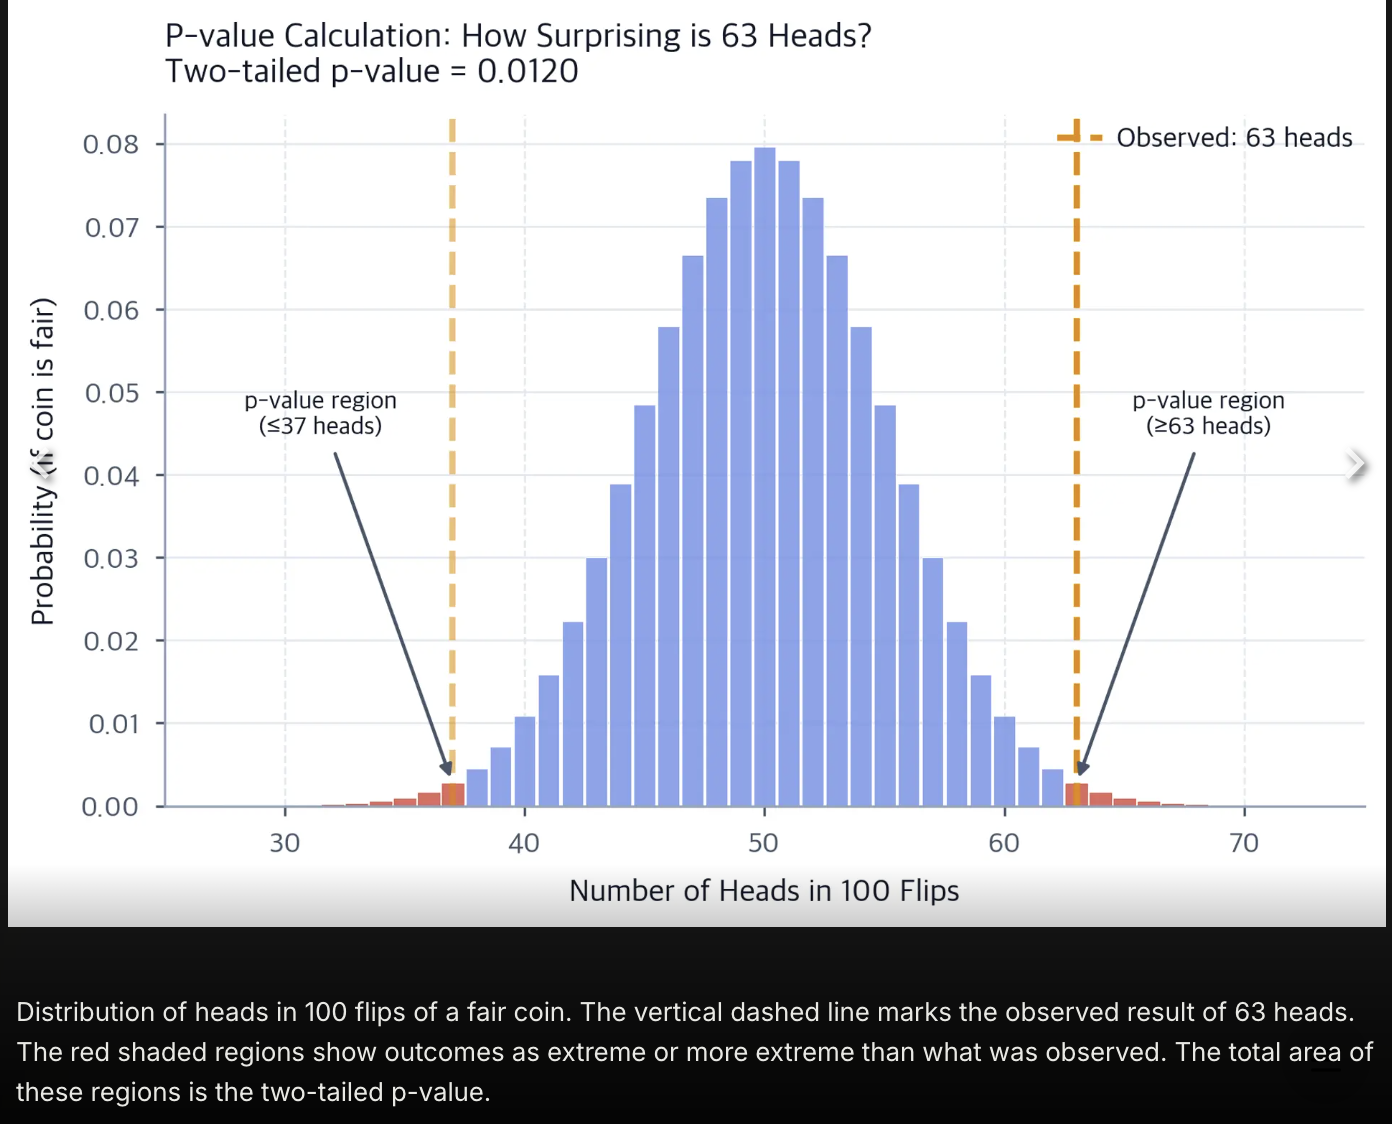

The p-value of about 0.012 tells us that if the coin were fair, we'd see a result this extreme only about 1.2% of the time. That's pretty surprising! It doesn't prove the coin is biased, but it suggests the "fair coin" assumption doesn't fit our data very well.



### Computing the P-Value Step By Step:

Let's work through the math explicitly. Under the null hypothesis that P(heads) = 0.5, the number of heads X follows a binomial distribution with n = 100 and p = 0.5:

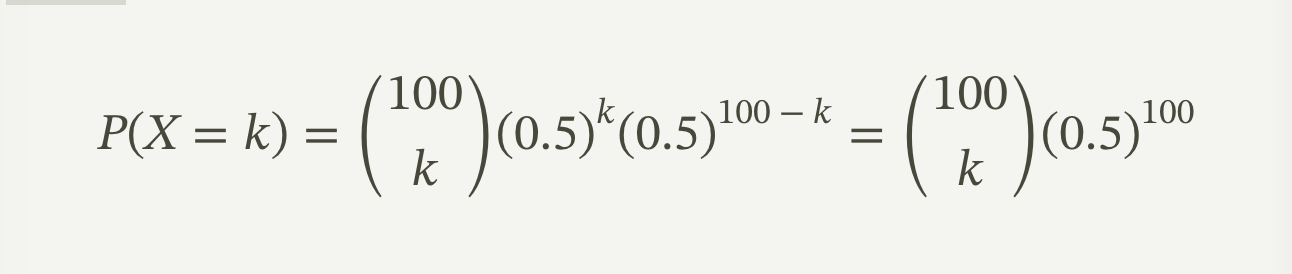

For a two-tailed test, we want the probability of being as extreme or more extreme than 63 in either direction. Since 63 is 13 away from the expected value of 50, we count outcomes of 63 or more heads, OR 37 or fewer heads:

$$p-value = P(X >= 63) + P(X<= 37)$$

By symmetry of the binomial distribution when p = 0.5:

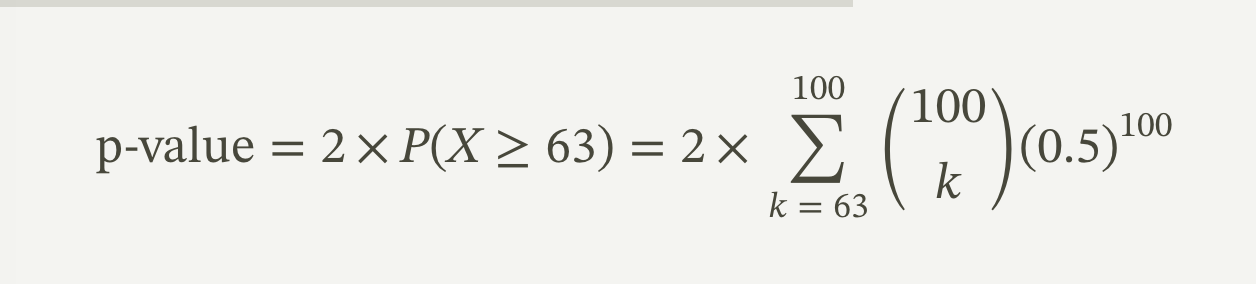

In [1]:
from scipy import stats

#Calculate exact p-value using binomial distribution
n = 100
p = 0.5
observed = 63

#P(X > = 63) = 1 - P(X < =62) = 1 - CDF(62)
p_right_tail = 1 - stats.binom.cdf(observed - 1, n,p)

#Two tailed p-value(by symmetry)
p_value = 2 * p_right_tail

print(f"P(X ≥ 63) = {p_right_tail:.6f}")
print(f"Two-tailed p-value = {p_value:.6f}")

P(X ≥ 63) = 0.006016
Two-tailed p-value = 0.012033


### what p-value Does not mean

Understanding what the p-value isn't is as important as understanding what it is. These three misinterpretations are incredibly common, even among experienced practitioners:

1. **Misinterpretation 1: "The p-value is the probability that the null hypothesis is true."**
This is wrong. The null hypothesis is either true or false. It's a fixed (but unknown) fact about reality, not a random variable. The p-value is about the probability of the data given the hypothesis, not the probability of the hypothesis given the data.

If you want to know P(hypothesis | data), you need Bayesian methods with prior probabilities. Classical hypothesis testing doesn't give you this.

2. **Misinterpretation 2: "1 minus the p-value is the probability the effect is real."**

A p-value of 0.02 also does not mean there's a 98% chance the alternative hypothesis is true. This is the same error as above, just phrased differently.

3. **Misinterpretation 3: "A small p-value means the effect is large or important."**

This interpretation is wrong because a tiny p-value can arise from a tiny effect with a huge sample size. If you test a million users, even a 0.001% difference in conversion rates might be "statistically significant" with p < 0.001, but that doesn't make it practically meaningful.

The p-value measures evidence against the null hypothesis, not the size or importance of an effect. Effect sizes, covered in a later chapter, address that question.


### Why P < 0.05 is a Convnetion , Not a Law

The threshold of 0.05 for "statistical significance" comes from Ronald Fisher, who in 1925 wrote that results below this threshold were "worth taking seriously." It was never meant to be a rigid cutoff.

Yet the 0.05 threshold has calcified into a binary decision rule that distorts research. A p-value of 0.049 gets published as "significant," while 0.051 gets buried as "not significant," despite conveying nearly identical evidence. This cliff encourages p-hacking, selective reporting, and publication bias.

Better practice is to:

- Report exact p-values, not just "p < 0.05"
- Interpret p-values on a continuum (0.001 is much stronger evidence than 0.04)
- Choose thresholds based on context (physics uses 5-sigma ≈ p < 0.0000003 for discoveries)
- Consider effect sizes alongside p-values

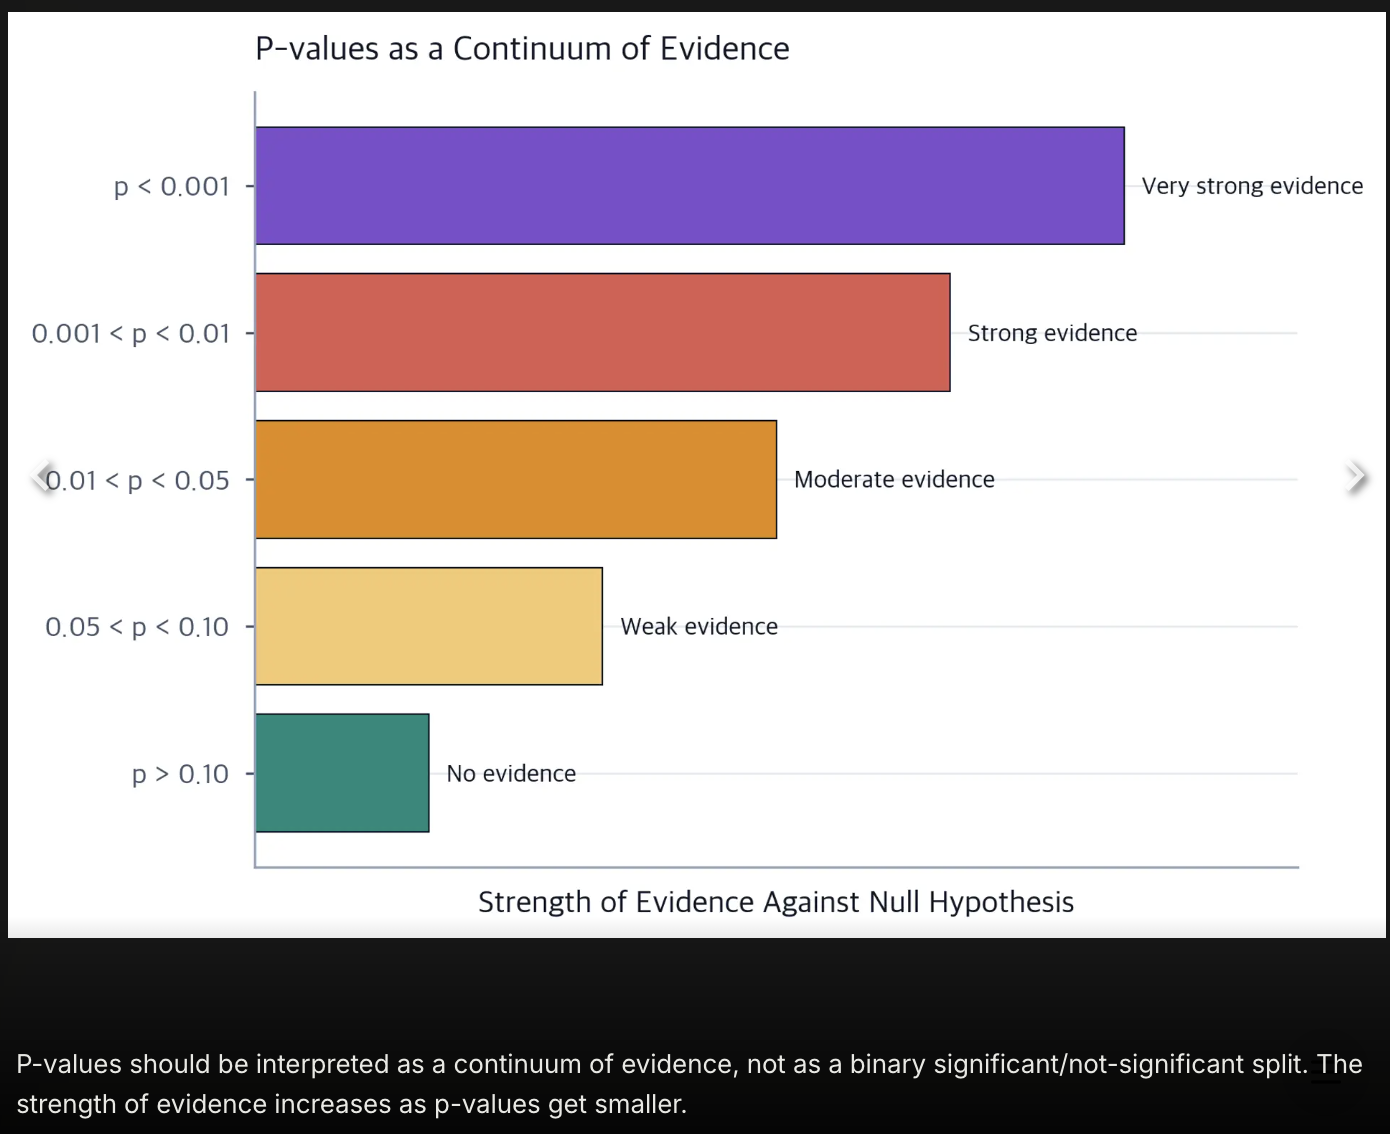

## 2. Setting Up a Hypothesis Test

With p-values understood, let's examine the mechanics of conducting a test. Every hypothesis test has the same structure: formulate hypotheses, choose a test, collect data, compute a test statistic, and make a decision.


### Null and Alternative Hypotheses

The **null hypothesis** ($H_{0}$) represents the skeptical position. It typically claims "nothing interesting is happening": no effect, no difference, no relationship. The null is what we assume true unless the data provide strong evidence otherwise.

The **alternative hypothesis** ($H_{a}or {H_{1}})is what we're trying to establish. It contradicts the null and represents the research claim.

**Example 1: Drug efficacy**:

- $H_{0}$ : The drug has no effect on blood pressure (mean change = 0)
- $H_{1}$: The drug affects blood pressure (mean change ≠ 0)

**Example 2: A/B Testing**:

- $H_{0}$: The new design has the same conversion rate as the old (rate_new = rate_old)
- $H_{1}$: The new design has a different conversion rate (rate_new ≠ rate_old)


**Example 2:Quality Control**:


- $H_{0}$: The machine is calibrated correctly (mean weight = 50g)
- $H_{1}$: The machine is miscalibrated (mean weight ≠ 50g)

>**The Asymmetry of Hypothesis Testing**
>We never "accept" the null hypothesis. We either **reject it** (if evidence is strong enough) or **fail to reject it** (if evidence is insufficient). Failing to reject doesn't prove the null is true. It just means we don't have enough evidence to claim otherwise. This asymmetry reflects the logic: we're testing whether the data are inconsistent with the null, not whether they prove it.


## One-Sided Vs Two-Sided Tests

The alternative hypothesis can be **directional** (one-sided) or **non-directional**  (two-sided).

A **two-sided test** considers alternatives in both direction:

- $H_{0}: \mu = \mu_{0}$
- $H_{1}: \mu \neq \mu_{0}$

Use this when deviations in either direction are scientifically meaningful. If you're testing whether a new drug affects blood pressure, you care whether it raises OR lowers it.

A **one-sided test** considers alternatives in both direction:
- $H_{0}: \mu = \mu_{0}(or \mu \leq \mu_{0})$
- $H_{1}: \mu > \mu_{0} (right-tailed)$

or 

- $H_{0}: \mu = \mu_{0}(or \mu \ge \mu_{0})$
- $H_{1}: \mu < \mu_{0} (left-tailed)$

Use this when only one direction matters. If you're testing whether a new treatment *improves outcomes*, you might not care if it makes things worse (that's a different problem).

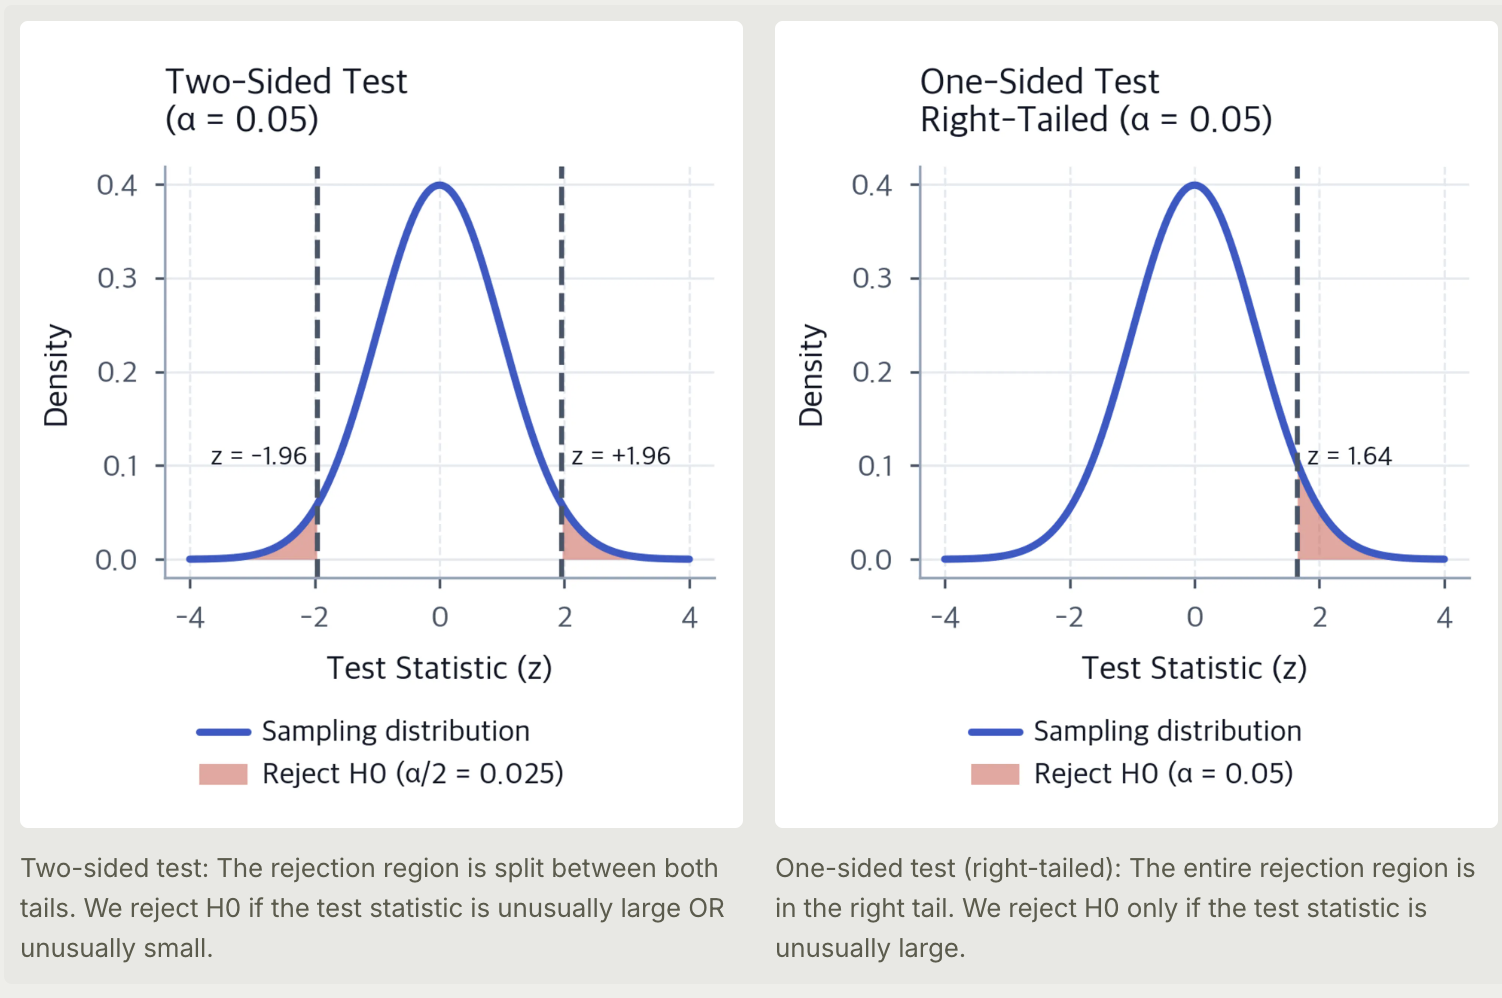

**The tradeoff**: One-sided tests have more power to detect effects in the hypothesized direction because the entire significance level is concentrated in one tail. But they completely miss effects in the opposite direction. If you use a right-tailed test and the true effect is negative, you'll never reject the null, no matter how strong the effect.

**Rule of thumb**: Unless you have a clear scientific reason to expect the effect in only one direction, use a two-sided test. It's more conservative and avoids interpretive problems.


## 3. The Test Statistic: Standardizing Evidence

Raw differences are meaningless without context. If I tell you my sample mean is 5 units above the hypothesized value, you can't assess the evidence without knowing how much variability to expect.

The **test statistic** solves this by standardizing the deviation. It answers: *"How many standard errors away from the null hypothesis is my observation?"*

**General Formula**

For most tests involving means, the *test statistic* takes this form:

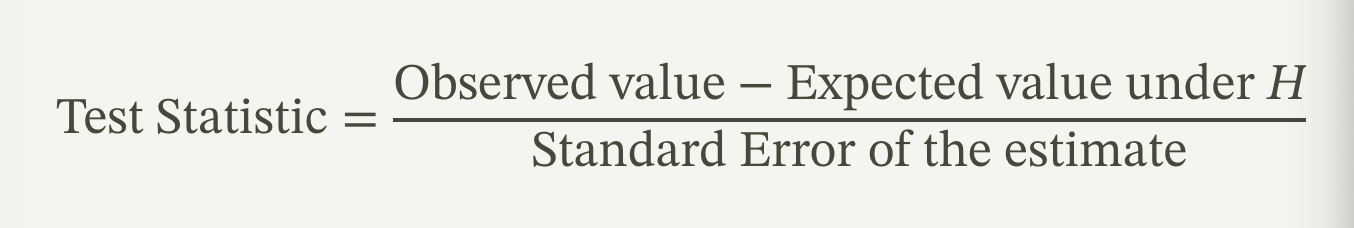

Let's break this down:

**Numerator:** How far is my observation from what the null predicts?

If $H_{0}$
claims the population mean is 100 and I observe a sample mean of 105, the numerator is 
$105 − 100 = 5$.


**Denominator**: How much random variation should I expect?

The standard error measures the typical sampling variation. For a sample mean, it's $σ / n$
(if we know the population standard deviation) or $s / \sqrt(n)$
(if we estimate it from the sample).

**The ratio:** How surprising is my observation?

A test statistic of 0.5 means my observation is half a standard error from the null. That's not surprising. A test statistic of 3 means my observation is 3 standard errors from the null. That's quite unusual.


**Example:Step-by-Step Calculation**
Let's work through a complete example. Suppose you want to test whether the average weight of packages from a production line differs from the target of 500g. You sample 25 packages and measure their weights.

**Step 1: State the Hypothesis**

-  $H_{0}:\mu$ = 500(the machine is calibrated correctly)
-  $H_{1}:\mu \neq $  500(the machine is calibirated)

**Step 2: Collect data and compute summary statistics**



In [2]:
import numpy as np

# Sample data: weights of 25 packages (in grams)
weights = np.array(
    [
        502,
        498,
        505,
        501,
        497,
        503,
        499,
        506,
        500,
        504,
        501,
        498,
        502,
        505,
        499,
        503,
        500,
        497,
        504,
        501,
        506,
        499,
        502,
        498,
        503,
    ]
)

# Summary Statistics
n = len(weights)
sample_mean = np.mean(weights)
sample_std = np.std(weights, ddof=1)# ddof=1 for sample standard deviation
standard_error = sample_std / np.sqrt(n)



print(f"Sample size: n = {n}")
print(f"Sample mean: x̄ = {sample_mean:.2f}g")
print(f"Sample standard deviation: s = {sample_std:.2f}g")
print(f"Standard error: SE = {standard_error:.2f}g")


Sample size: n = 25
Sample mean: x̄ = 501.32g
Sample standard deviation: s = 2.78g
Standard error: SE = 0.56g


**Step 3: Calculate the test statistic**
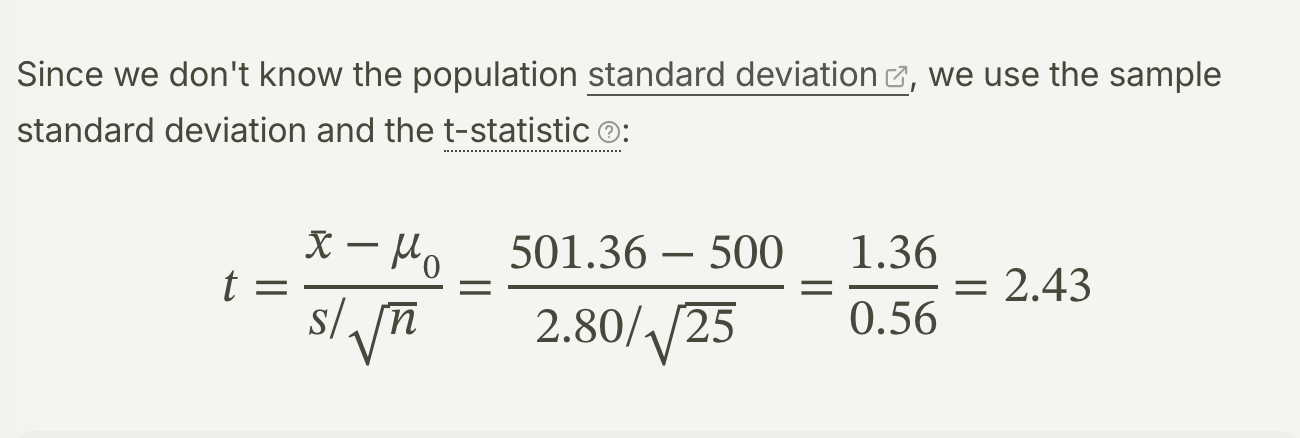

In [3]:
# Calculate t-statistic
hypothesized_mean = 500
t_stat = (sample_mean - hypothesized_mean) / standard_error

print(f"t-statistic: t = {t_stat:.3f}")

t-statistic: t = 2.374


**Step 4: Find the p-value**

The t-statistic follows a t-distribution with 
$n − 1 = 24$
degrees of freedom. For a two-sided test, we need the probability of being as extreme or more extreme than our observed t-statistic in either direction:

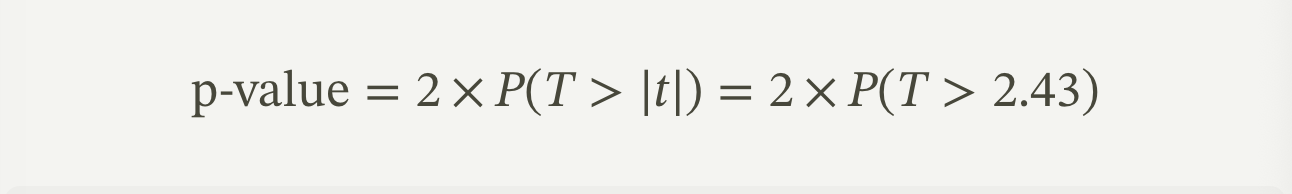



In [4]:
# Calculate two-sided p-value
df = n - 1
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=df))

print(f"Degrees of freedom: df = {df}")
print(f"Two-sided p-value: p = {p_value:.4f}")

Degrees of freedom: df = 24
Two-sided p-value: p = 0.0259


**Step 5: Make a decision**

At the conventional $α = 0.05$ significance level, our p-value of $0.023$ is less than $0.05$. We reject the null hypothesis and conclude there's statistically significant evidence that the mean weight differs from 500g.

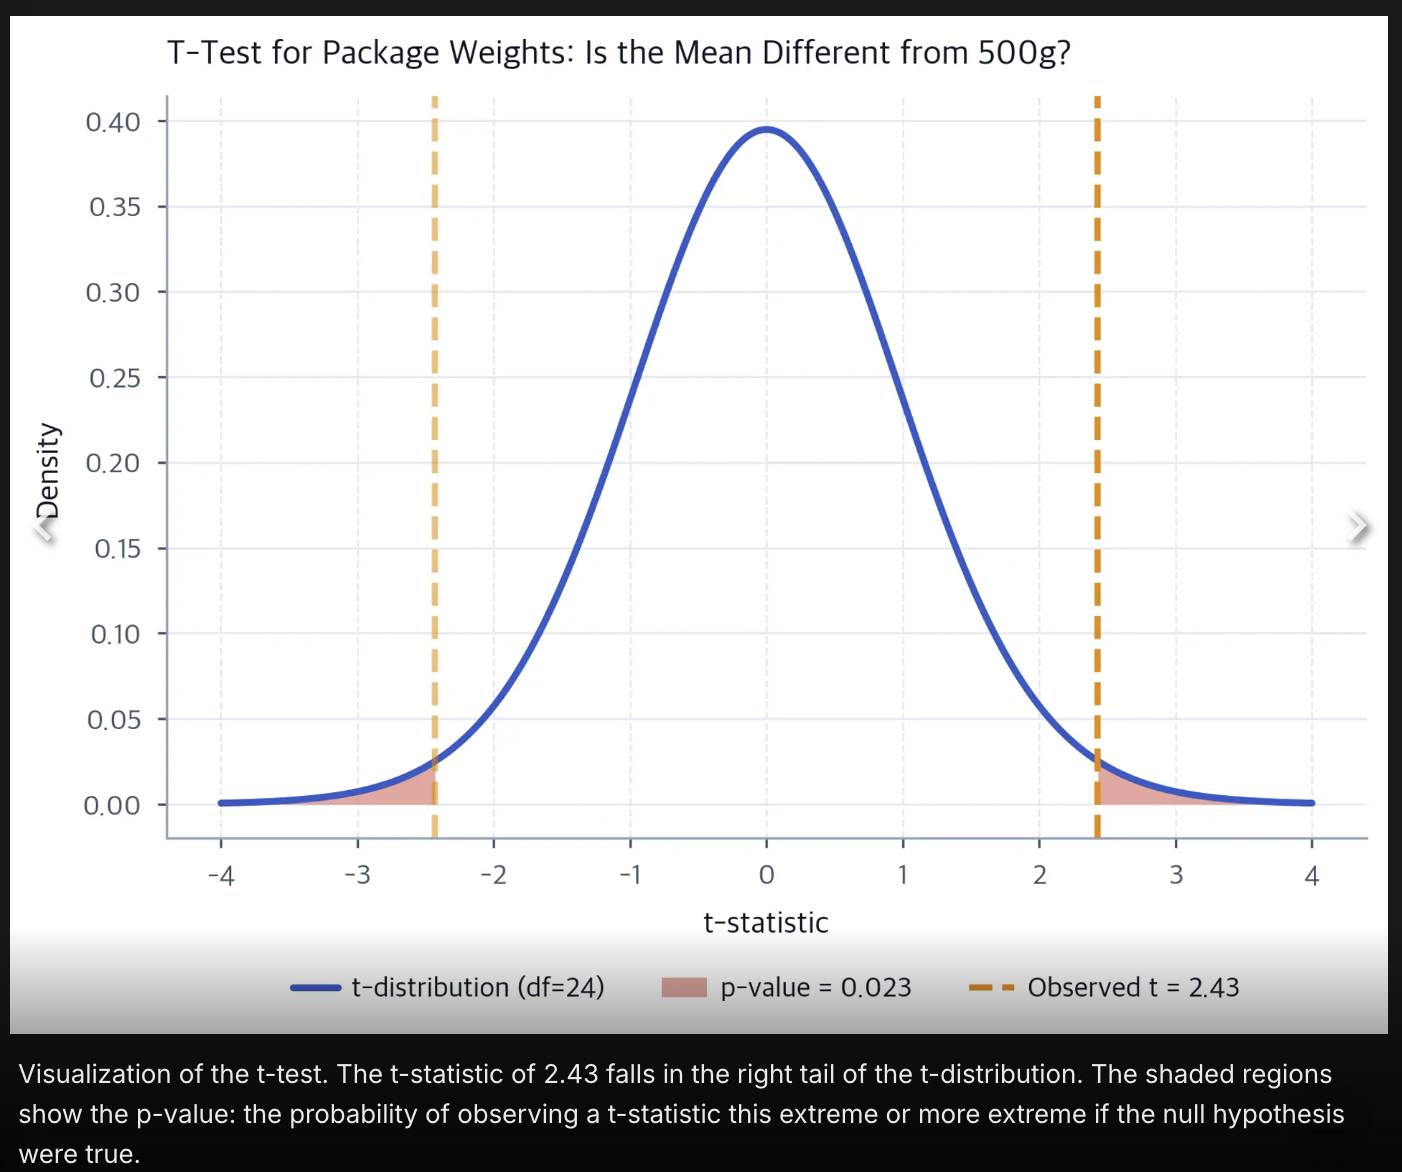

## 4. Why Sample Size Matters

The standard error 
$s/\sqrt{n}$ shrinks as sample size grows, but not linearly. It shrinks proportionally to $n$:

- 4× the sample size → 2× smaller standard error
- 100× the sample size → 10× smaller standard error

This has important implications:

- **Larger samples detect smaller effects**: With enough data, even tiny differences become "statistically significant."
- **Diminishing returns**: Each additional observation contributes less than the previous one. Quadrupling your sample only halves your uncertainty.
- **Statistical vs practical significance**: A huge sample might find a "significant" effect that's too small to matter in practice.

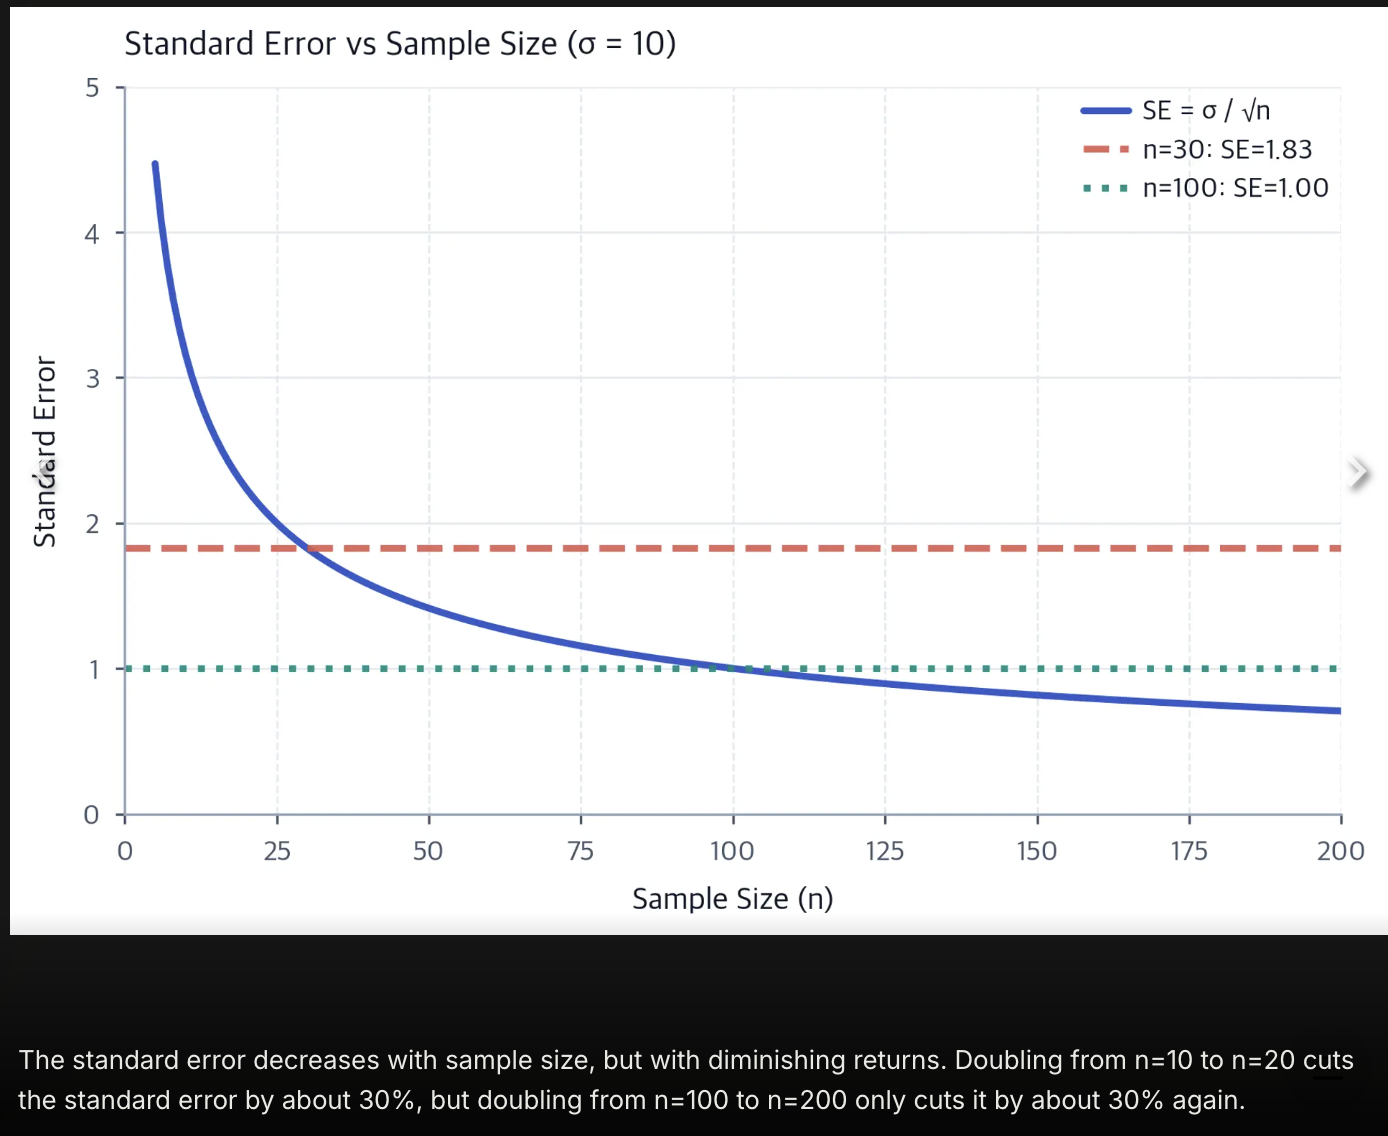



## 5. The Decision Process

We've calculated our test statistic and p-value. Now what? The decision follows this logic:

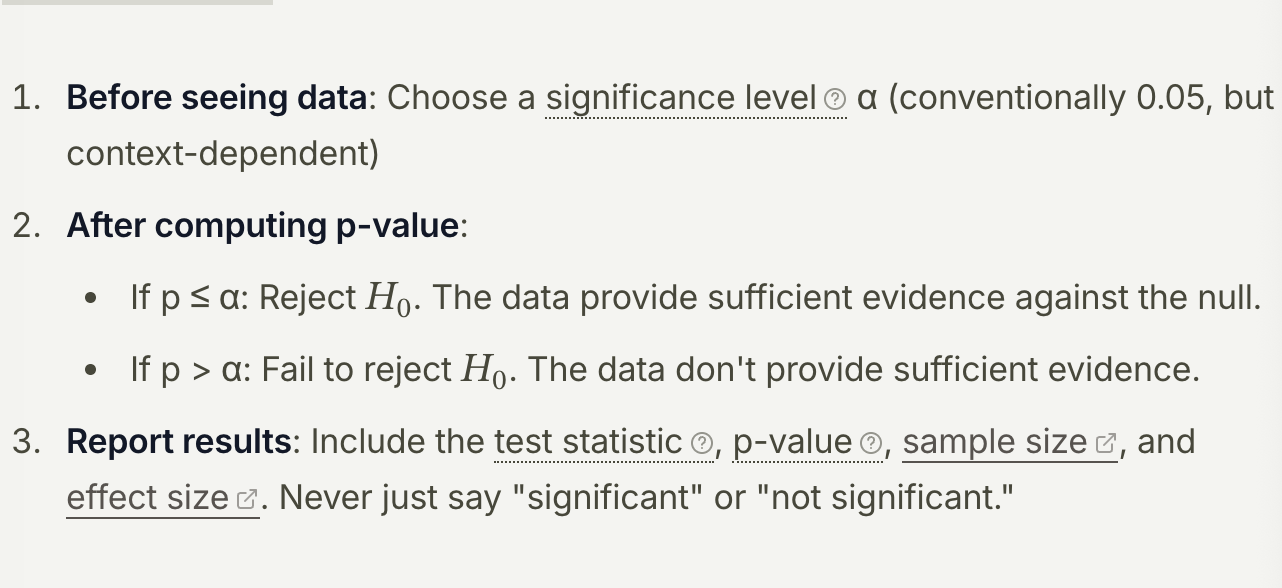

>**The Critical Value Approach**
>- An equivalent approach uses **critical values** instead of p-values. The critical value is the test statistic boundary separating "reject" from "fail to reject."
>- For a two-sided z-test at α = 0.05, the critical values are ±1.96. You reject $H_0$ if |z| > 1.96.
>- For a two-sided t-test, critical values depend on degrees of freedom. With df = 24 and α = 0.05, the critical values are approximately ±2.064
>- Both approaches give the same answer. The p-value approach is more informative because it tells you exactly how extreme your result was.



## Summary

This chapter established the foundations of hypothesis testing:

- The logic: We assume the null hypothesis is true and ask how surprising our data would be under that assumption. If the data are surprising enough (low p-value), we reject the null.

- P-values: The probability of observing data as extreme as ours, assuming the null is true. P-values measure evidence against the null, not the probability the null is true, and not the size of any effect.

- Hypotheses: The null (
$H_0$) is the skeptical position; the alternative (
$H_1$) is what we're trying to establish. We never accept 
$H_0$; we either reject it or fail to reject it.

- One-sided vs two-sided: Two-sided tests are the default. Use one-sided only when effects in one direction are meaningless.

- Test statistics: Standardize the observed deviation by the expected variability. This allows comparison across different contexts and scales.

- Decisions: Compare the p-value to your significance level α. Report exact p-values, not just "significant" or "not significant."

